In [54]:
import os
os.chdir(r'C:\Users\66959\Desktop\stats\data')
os.getcwd()

'C:\\Users\\66959\\Desktop\\stats\\data'

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [56]:
orig_df1 = pd.read_csv('worldbank_2017_2021.csv')
orig_df2 = pd.read_excel('countries_regions.xlsx')

In [57]:
orig_df = pd.merge(orig_df1, orig_df2, left_on='Country Name', right_on='CountryName')

In [58]:
orig_df.head()

,Country Name,Year,Agricultural irrigated land (% of total agricultural land),Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),...,"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)",Firms with female participation in ownership (% of firms),Firms with female top manager (% of firms),"Proportion of time spent on unpaid domestic and care work, female (% of 24 hour day)","Proportion of time spent on unpaid domestic and care work, male (% of 24 hour day)","Women making their own informed decisions regarding sexual relations, contraceptive use and reproductive health care (% of women age 15-49)",CountryName,Region,ThirdWorld
0,Afghanistan,2017,5.99,58.12,26.42,11.80,2091.4,99.21,20.45,99.84,...,62.58,12.20,NaN,NaN,NaN,NaN,NaN,Afghanistan,South Asia,Yes
1,Albania,2017,14.56,42.86,19.02,22.34,4813.0,105.84,99.81,103.88,...,29.97,17.04,NaN,NaN,NaN,NaN,NaN,Albania,Eastern Europe,No
2,Algeria,2017,3.16,17.36,11.03,3.14,990.3,104.40,20.84,102.87,...,2.33,1.70,NaN,NaN,NaN,NaN,NaN,Algeria,Africa,No
3,American Samoa,2017,NaN,13.90,NaN,4.65,NaN,NaN,41.67,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,American Samoa,Australia and Oceanea,No
4,Andorra,2017,NaN,40.04,0.56,1.74,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Andorra,Western Europe,No


In [59]:
orig_df = orig_df.drop(columns=['CountryName'])

In [60]:
df = orig_df.copy()

In [61]:
df.shape

(1070, 197)

# Train-test split

In [62]:
X = df.drop(columns=["GNI per capita, PPP (current international $)"])
y = df["GNI per capita, PPP (current international $)"]

In [63]:
mask = y.notna()

X = X.loc[mask]
y = y.loc[mask]

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=99)

In [65]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((772, 196), (194, 196), (772,), (194,))

# Data preprocessing 

## Handling missing values

In [66]:
print((X_train.isna().mean() * 100).to_string())

Country Name                                                                                                                                     0.000000
Year                                                                                                                                             0.000000
Agricultural irrigated land (% of total agricultural land)                                                                                      74.352332
Agricultural land (% of land area)                                                                                                               2.072539
Agriculture, forestry, and fishing, value added (% of GDP)                                                                                       4.663212
Arable land (% of land area)                                                                                                                     3.367876
Cereal yield (kg per hectare)                                               

In [67]:
print((y_train.isna().mean() * 100))

0.0


In [68]:
threshold = 0.40
missing_ratio = X_train.isna().mean()
drop_cols = missing_ratio[missing_ratio > threshold].index

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [69]:
num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include=['object','category']).columns

In [70]:
cat_cols

Index(['Country Name', 'Region', 'ThirdWorld'], dtype='object')

In [71]:
X_train[num_cols] = X_train[num_cols].fillna(X_train[num_cols].median())
X_test[num_cols] = X_test[num_cols].fillna(X_train[num_cols].median())

X_train[cat_cols] = X_train[cat_cols].fillna(X_train[cat_cols].mode())
X_test[cat_cols] = X_test[cat_cols].fillna(X_train[cat_cols].mode())

In [72]:
print((X_train.isna().mean() * 100).to_string())

Country Name                                                                                       0.0
Year                                                                                               0.0
Agricultural land (% of land area)                                                                 0.0
Agriculture, forestry, and fishing, value added (% of GDP)                                         0.0
Arable land (% of land area)                                                                       0.0
Cereal yield (kg per hectare)                                                                      0.0
Crop production index (2014-2016 = 100)                                                            0.0
Fertilizer consumption (kilograms per hectare of arable land)                                      0.0
Food production index (2014-2016 = 100)                                                            0.0
Forest area (% of land area)                                             

## Handling Outliers

In [73]:
def remove_outliers_sync(X, y, outlier_vars):
    combined = pd.concat([X, y], axis=1)
    target_col = y.name
    
    for _var in outlier_vars:
        if pd.api.types.is_numeric_dtype(combined[_var]) and combined[_var].dtype != 'bool':
            q1 = combined[_var].quantile(0.25)
            q3 = combined[_var].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            
            combined = combined[(combined[_var] >= lower_bound) & (combined[_var] <= upper_bound)]
            
    return combined.drop(columns=[target_col]), combined[target_col]

## Handling Skewness

In [74]:
X_train 

,Country Name,Year,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),...,High-technology exports (current US$),"International tourism, expenditures (% of total imports)",Medium and high-tech exports (% manufactured exports),Merchandise exports (current US$),Merchandise imports (current US$),Merchandise trade (% of GDP),"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)",Region,ThirdWorld
249,Canada,2018,6.46,1.70,4.32,3914.7,107.06,111.81,108.98,38.70,...,3.048048e+10,5.56,55.74,4.520000e+11,4.690000e+11,53.41,0.16,0.10,North America,No
666,Bosnia and Herzegovina,2020,43.79,5.91,19.82,6050.7,129.61,82.46,115.06,42.73,...,2.120509e+08,1.68,28.83,6.155000e+09,9.873000e+09,79.24,5.49,1.46,Eastern Europe,No
868,Azerbaijan,2021,57.84,5.73,25.28,3297.4,142.51,105.59,126.99,13.83,...,2.221287e+07,5.56,40.11,2.220800e+10,1.170300e+10,61.85,37.32,24.31,Western Asia,No
982,Mexico,2021,49.96,3.79,10.33,3878.9,111.91,109.25,114.11,33.73,...,7.498157e+10,5.56,79.22,4.950000e+11,5.220000e+11,77.48,6.09,2.90,North America,No
1044,Syrian Arab Republic,2021,75.77,27.82,25.38,820.4,100.49,3.86,100.59,2.84,...,7.878630e+07,5.56,22.69,3.914000e+09,6.136000e+09,111.91,2.26,0.76,Middle East,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
790,Pakistan,2020,47.64,21.85,40.12,3353.4,105.14,155.15,115.98,4.83,...,3.093933e+08,2.39,11.13,2.197900e+10,4.583700e+10,22.57,56.22,11.28,South Asia,No
186,Sweden,2017,7.39,1.44,6.27,5992.3,103.35,104.97,100.86,68.69,...,1.710788e+10,5.56,60.05,1.530000e+11,1.540000e+11,56.77,0.23,0.21,Northern Europe,No
203,United Arab Emirates,2017,5.40,0.76,0.63,30801.8,98.67,708.50,107.31,4.47,...,5.236689e+08,5.56,20.40,3.140000e+11,2.580000e+11,146.30,0.21,0.06,Middle East,No
39,Chile,2017,16.23,4.28,1.75,6779.4,100.41,349.88,98.85,24.00,...,6.348690e+08,4.06,9.96,6.882300e+10,6.523000e+10,48.54,1.80,0.72,South America,No


In [75]:
skewness = X_train[num_cols].skew().sort_values(ascending=False)

threshold = 0.75
high_skew_columns = skewness[abs(skewness) > threshold].index.tolist()

skewness

Fertilizer consumption (kilograms per hectare of arable land)     27.010231
Inflation, consumer prices (annual %)                             13.762841
Container port traffic (TEU: 20 foot equivalent units)            11.125975
Annual freshwater withdrawals, total (% of internal resources)    11.052837
Labor force, total                                                10.311653
                                                                    ...    
Access to electricity (% of population)                           -1.774450
Immunization, DPT (% of children ages 12-23 months)               -1.919566
School enrollment, primary (gross), gender parity index (GPI)     -1.932593
Net migration                                                     -3.145853
Population, female (% of total population)                        -4.726802
Length: 104, dtype: float64

In [76]:
def fit_transform_skew(train_df, skew_cols):
    from sklearn.preprocessing import PowerTransformer
    train_res = train_df.copy()
    pt = PowerTransformer(method='yeo-johnson')
    train_res[skew_cols] = pt.fit_transform(train_df[skew_cols])
    return train_res, pt

In [77]:
X_train, pt_model = fit_transform_skew(X_train, high_skew_columns)
X_test[high_skew_columns] = pt_model.transform(X_test[high_skew_columns])

In [78]:
X_train[num_cols].skew().sort_values(ascending=False)

Net official development assistance received (current US$)                                         3.979377
GDP growth (annual %)                                                                              3.306050
Age dependency ratio (% of working-age population)                                                 0.724125
Vulnerable employment, male (% of male employment) (modeled ILO estimate)                          0.694613
Fixed broadband subscriptions (per 100 people)                                                     0.681319
                                                                                                     ...   
Labor force participation rate, female (% of female population ages 15+) (modeled ILO estimate)   -0.667954
Net lending (+) / net borrowing (-) (% of GDP)                                                    -0.670894
Access to electricity (% of population)                                                           -1.168935
Current account balance (BoP

## Encoding

In [79]:
cat_cols

Index(['Country Name', 'Region', 'ThirdWorld'], dtype='object')

In [80]:
X_train.shape

(772, 107)

In [81]:
def onehot_encoder_selected(df, encoded_vars):
    df = pd.get_dummies(df, columns=encoded_vars, drop_first=True)
    return df

In [82]:
X_train = onehot_encoder_selected(X_train, cat_cols)
X_test = onehot_encoder_selected(X_test, cat_cols)

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

In [83]:
X_train.shape

(772, 310)

In [84]:
X_test.shape

(194, 310)

## Scaling

In [85]:
from sklearn.preprocessing import StandardScaler

def scale_standard(X_train, X_test):
    scaler = StandardScaler()
    
    train_arr = scaler.fit_transform(X_train)
    test_arr = scaler.transform(X_test)

    X_train_scaled = pd.DataFrame(train_arr, columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(test_arr, columns=X_test.columns, index=X_test.index)
    
    return X_train_scaled, X_test_scaled

# Feature selection

In [86]:
X_train.head()

,Year,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),...,Region_Middle East,Region_North America,Region_Northern Europe,Region_South America,Region_South Asia,Region_Southeast Asia,Region_Thailand,Region_Western Asia,Region_Western Europe,ThirdWorld_Yes
249,2018,6.46,-1.030473,-0.636408,0.385396,0.153862,0.294208,0.292202,38.70,2.422545,...,False,True,False,False,False,False,False,False,False,False
666,2020,43.79,-0.075013,0.759408,1.055755,1.444569,0.098582,0.706650,42.73,0.124462,...,False,False,False,False,False,False,False,False,False,False
868,2021,57.84,-0.102499,1.028530,0.141128,2.113487,0.257167,1.439982,13.83,-0.096744,...,False,False,False,False,False,False,False,True,False,False
982,2021,49.96,-0.453223,0.100424,0.372044,0.446433,0.279204,0.643864,33.73,1.539723,...,False,True,False,False,False,False,False,False,False,False
1044,2021,75.77,1.470604,1.033000,-1.487249,-0.257584,-1.611248,-0.333854,2.84,-0.346043,...,True,False,False,False,False,False,False,False,False,False


## Low Variance Filtering

In [87]:
X_train.var().sort_values(ascending=False)

Vulnerable employment, female (% of female employment) (modeled ILO estimate)    829.660216
School enrollment, preprimary (% gross)                                          729.024722
School enrollment, tertiary (% gross)                                            618.715316
Forest area (% of land area)                                                     600.587867
Rural population (% of total population)                                         562.975104
                                                                                    ...    
Country Name_Belarus                                                               0.002587
Country Name_Nicaragua                                                             0.002587
Country Name_Netherlands                                                           0.002587
Country Name_India                                                                 0.001295
Country Name_Cameroon                                                           

In [88]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0)
selector.fit(X_train)

updated_vars = X_train.columns[selector.get_support()].tolist()
updated_vars

['Year',
 'Agricultural land (% of land area)',
 'Agriculture, forestry, and fishing, value added (% of GDP)',
 'Arable land (% of land area)',
 'Cereal yield (kg per hectare)',
 'Crop production index (2014-2016 = 100)',
 'Fertilizer consumption (kilograms per hectare of arable land)',
 'Food production index (2014-2016 = 100)',
 'Forest area (% of land area)',
 'Forest area (sq. km)',
 'Land area (sq. km)',
 'Livestock production index (2014-2016 = 100)',
 'Permanent cropland (% of land area)',
 'Rural population',
 'Rural population (% of total population)',
 'Surface area (sq. km)',
 'Access to electricity (% of population)',
 'Annual freshwater withdrawals, total (% of internal resources)',
 'Mortality rate, under-5 (per 1,000 live births)',
 'Population growth (annual %)',
 'Population, total',
 'Primary completion rate, total (% of relevant age group)',
 'Renewable energy consumption (% of total final energy consumption)',
 'Urban population',
 'Urban population (% of total popu

In [89]:
len(updated_vars)

310

In [90]:
X_train = X_train[updated_vars]
X_test = X_test[updated_vars]
X_train.head()

,Year,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),...,Region_Middle East,Region_North America,Region_Northern Europe,Region_South America,Region_South Asia,Region_Southeast Asia,Region_Thailand,Region_Western Asia,Region_Western Europe,ThirdWorld_Yes
249,2018,6.46,-1.030473,-0.636408,0.385396,0.153862,0.294208,0.292202,38.70,2.422545,...,False,True,False,False,False,False,False,False,False,False
666,2020,43.79,-0.075013,0.759408,1.055755,1.444569,0.098582,0.706650,42.73,0.124462,...,False,False,False,False,False,False,False,False,False,False
868,2021,57.84,-0.102499,1.028530,0.141128,2.113487,0.257167,1.439982,13.83,-0.096744,...,False,False,False,False,False,False,False,True,False,False
982,2021,49.96,-0.453223,0.100424,0.372044,0.446433,0.279204,0.643864,33.73,1.539723,...,False,True,False,False,False,False,False,False,False,False
1044,2021,75.77,1.470604,1.033000,-1.487249,-0.257584,-1.611248,-0.333854,2.84,-0.346043,...,True,False,False,False,False,False,False,False,False,False


## High Correlation Filtering

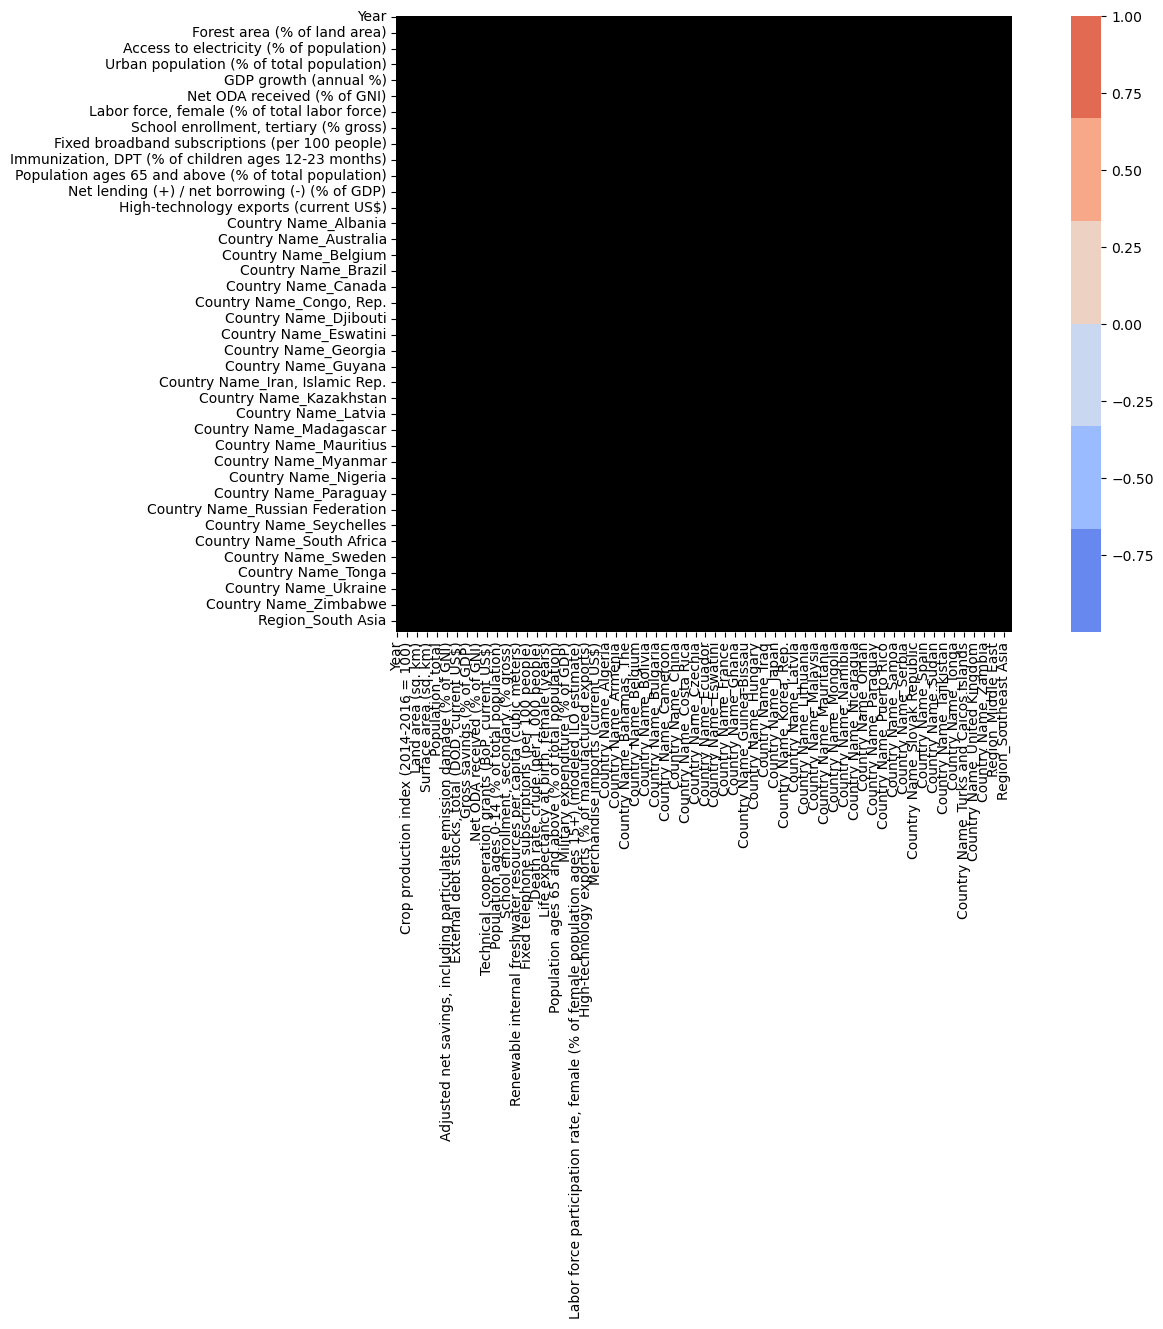

In [91]:
plt.figure(figsize=(15,8))
sns.heatmap(X_train.corr(),
            square=True,
            linewidths=0.25,    
            linecolor=(0,0,0),
            cmap=sns.color_palette("coolwarm"),
            annot=False)
plt.show()

In [92]:
import numpy as np

def drop_high_corr_cols_with_target(X, y, threshold=0.8):
    corr = X.corr().abs()
    target_corr = X.apply(lambda col: col.corr(y)).abs()

    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    drop_cols = set()

    for col in upper.columns:
        high_corr = upper[col][upper[col] > threshold].index
        for other in high_corr:
            if target_corr[col] < target_corr[other]:
                drop_cols.add(col)
            else:
                drop_cols.add(other)

    return list(drop_cols)

In [93]:
drop_cols = drop_high_corr_cols_with_target(X_train, y_train, threshold=0.8)

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [94]:
X_train.shape

(772, 280)

In [95]:
X_test.shape

(194, 280)

# Modeling 

In [96]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def compute_regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

def compute_mape(y_true, y_pred):
    # Mean Absolute Percentage Error
    # Note: MAPE fails if y_true contains zeros.
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def compute_smape(y_true, y_pred):
    # Symmetric Mean Absolute Percentage Error
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

def compute_rmsle(y_true, y_pred, neg_mask=0):
    # Root Mean Squared Log Error
    # RMSLE is good for right-skewed data
    # Note: log1p(x) = log(1+x), and the log parameter must be positive. 
    # Therefore, x >= -1. Otherwise, log1p(1+x) encounters an invalid value.
        
    if neg_mask == 1:
        mask = (y_true >= 0) & (y_pred >= 0)
        y_true = y_true[mask]
        y_pred = y_pred[mask]
    
    np_y_true, np_y_pred = np.array(y_true), np.array(y_pred)
    rmsle = np.sqrt(np.mean((np.log1p(np_y_true) - np.log1p(np_y_pred))**2))  # Root Mean Squared Log Error

    return rmsle

In [97]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import r2_score, mean_absolute_percentage_error

model = LinearRegression()

results = []

for k in range(10, 101, 10):
    rfe = RFE(estimator=model, n_features_to_select=k)
    rfe.fit(X_train, y_train)
    

    Xtr = X_train.loc[:, rfe.support_]
    Xte = X_test.loc[:, rfe.support_]

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)


    score = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    
    results.append((k, score, mape))
    print(f"Features: {k} | R2 Score: {score:.4f} | MAPE: {mape:.4f}")

Features: 10 | R2 Score: 0.3829 | MAPE: 2.0935
Features: 20 | R2 Score: 0.5511 | MAPE: 1.8412
Features: 30 | R2 Score: 0.9125 | MAPE: 0.5511
Features: 40 | R2 Score: 0.9393 | MAPE: 0.4342
Features: 50 | R2 Score: 0.9418 | MAPE: 0.4302
Features: 60 | R2 Score: 0.9437 | MAPE: 0.4054
Features: 70 | R2 Score: 0.9507 | MAPE: 0.3409
Features: 80 | R2 Score: 0.9515 | MAPE: 0.3235
Features: 90 | R2 Score: 0.9605 | MAPE: 0.2587
Features: 100 | R2 Score: 0.9625 | MAPE: 0.2546


In [98]:
rfe = RFE(model, n_features_to_select=90)
rfe.fit(X_train, y_train)
best_features = X_train.columns[rfe.support_].tolist()
print(best_features)

['Agriculture, forestry, and fishing, value added (% of GDP)', 'Rural population', 'Merchandise imports (current US$)', 'Merchandise trade (% of GDP)', 'Country Name_Algeria', 'Country Name_Andorra', 'Country Name_Argentina', 'Country Name_Aruba', 'Country Name_Australia', 'Country Name_Austria', 'Country Name_Bahrain', 'Country Name_Barbados', 'Country Name_Belize', 'Country Name_Bermuda', 'Country Name_Brazil', 'Country Name_Brunei Darussalam', 'Country Name_Cabo Verde', 'Country Name_Cameroon', 'Country Name_Canada', 'Country Name_Colombia', 'Country Name_Costa Rica', 'Country Name_Curacao', 'Country Name_Cyprus', 'Country Name_Denmark', 'Country Name_Djibouti', 'Country Name_Ecuador', 'Country Name_El Salvador', 'Country Name_Equatorial Guinea', 'Country Name_Estonia', 'Country Name_Faroe Islands', 'Country Name_Germany', 'Country Name_Ghana', 'Country Name_Grenada', 'Country Name_Guatemala', 'Country Name_Guyana', 'Country Name_Honduras', 'Country Name_Hungary', 'Country Name_Icel

In [99]:
X_train, y_train = remove_outliers_sync(X_train, y_train, best_features)

In [106]:
X_train.shape

(745, 90)

In [100]:
X_train = X_train[best_features]
X_test = X_test[best_features]

In [101]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Use model for predicted responses
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

# Measure performances
rmse, mae, r2 = compute_regression_metrics(y_test, y_pred)
mape = compute_mape(y_test, y_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)
rmsle = compute_rmsle(y_test, y_pred)
print("RMSLE: ", rmsle)

RMSE:  4709.564018289054
MAE:  2942.2583569783483
MAPE:  28.327221486325595
R2:  0.9580944484997369
RMSLE:  nan


C:\Users\66959\AppData\Local\Temp\ipykernel_2788\271000135.py:32: RuntimeWarning: invalid value encountered in log1p
  rmsle = np.sqrt(np.mean((np.log1p(np_y_true) - np.log1p(np_y_pred))**2))  # Root Mean Squared Log Error


# Performance evaluation

In [102]:
rmse, mae, r2 = compute_regression_metrics(y_test, y_pred)
mape = compute_mape(y_test, y_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)
rmsle = compute_rmsle(y_test, y_pred)
print("RMSLE: ", rmsle)

RMSE:  4709.564018289054
MAE:  2942.2583569783483
MAPE:  28.327221486325595
R2:  0.9580944484997369
RMSLE:  nan


C:\Users\66959\AppData\Local\Temp\ipykernel_2788\271000135.py:32: RuntimeWarning: invalid value encountered in log1p
  rmsle = np.sqrt(np.mean((np.log1p(np_y_true) - np.log1p(np_y_pred))**2))  # Root Mean Squared Log Error


In [103]:
coeff_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

print(coeff_df)

                                              Feature   Coefficient
0   Agriculture, forestry, and fishing, value adde...  -2797.057346
1                                    Rural population -11835.171108
2                   Merchandise imports (current US$)  12741.809972
3                        Merchandise trade (% of GDP)  -3044.062776
4                                Country Name_Algeria  -5344.838457
..                                                ...           ...
85                                Country Name_Zambia  -5281.439063
86                              Country Name_Zimbabwe  -6388.689068
87                             Region_Northern Europe  14727.415853
88                               Region_South America  -5692.346199
89                              Region_Western Europe   9672.136947

[90 rows x 2 columns]


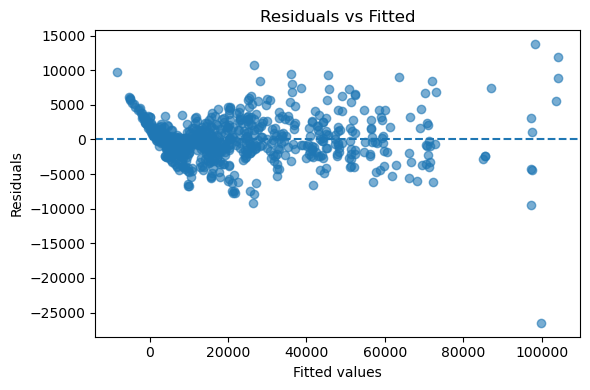

In [104]:
residuals = y_train - y_train_pred

plt.figure(figsize=(6,4))
plt.scatter(y_train_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')

plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

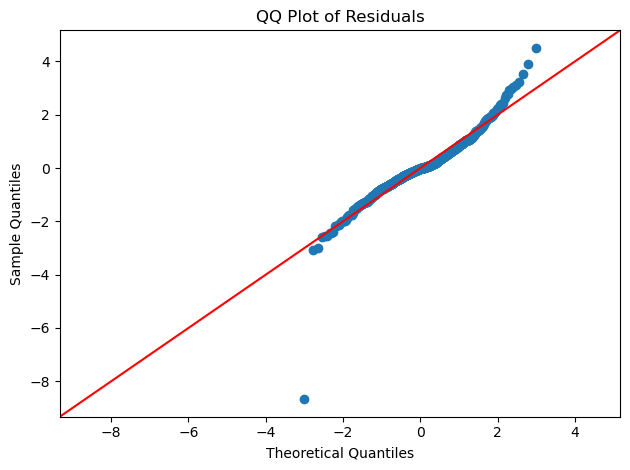

In [105]:
residuals = y_train - y_train_pred

# QQ plot
plt.figure(figsize=(6,4))
sm.qqplot(residuals, line='45', fit=True)
plt.title('QQ Plot of Residuals')
plt.tight_layout()
plt.show()